### 实验03：线性度与灵敏度测试

#### 实验内容
1. 多点力-输出标定
2. 线性回归拟合
3. 线性度误差计算（端基线性度、最小二乘线性度）
4. 灵敏度计算
5. R²决定系数与RMSE计算

#### 输入数据说明
- 文件格式：CSV，三列数据（Time_ms, RawValue, RawGround）
- 文件夹结构：主路径下包含 0, 1, 2, ... 编号子文件夹
- 每个子文件夹包含一个或多个CSV文件
- 力值由用户在配置中指定

#### 1. 导入库与参数配置

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import os, glob, sys

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
from plot_style import apply_measurement_style, COLORS, add_subplot_label, save_figure, SAVE_DIRS

apply_measurement_style()
SAVE_DIR = SAVE_DIRS[3]

V_REF = 5.0
LSB = V_REF / (2**15)

#### 2. 数据加载函数

In [2]:
def load_sensor_data(file_path):
    """加载传感器CSV数据"""
    df = pd.read_csv(file_path)
    df.columns = ['Time_ms', 'RawValue', 'RawGround']
    return df

def extract_stable_mean(df, start_ratio=0.2, end_ratio=0.8):
    """提取稳定区间的均值和标准差"""
    n = len(df)
    start_idx = int(n * start_ratio)
    end_idx = int(n * end_ratio)
    stable_data = df['RawValue'].iloc[start_idx:end_idx]
    return np.mean(stable_data), np.std(stable_data)

def get_csv_files_in_folder(folder_path):
    """获取文件夹内所有CSV文件，按时间戳排序"""
    pattern = os.path.join(folder_path, "*.csv")
    files = glob.glob(pattern)
    files.sort()  # 按文件名排序
    return files

def load_folder_data(folder_path):
    """加载文件夹内所有CSV文件，返回合并后的均值"""
    csv_files = get_csv_files_in_folder(folder_path)
    if len(csv_files) == 0:
        return None, None
    
    means = []
    stds = []
    for f in csv_files:
        df = load_sensor_data(f)
        mean_val, std_val = extract_stable_mean(df)
        means.append(mean_val)
        stds.append(std_val)
    
    # 如果有多个文件，取平均值
    return np.mean(means), np.mean(stds)

#### 3. 配置数据路径与力值

In [3]:
_BASE = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "..", "workspace", "test3")
BASE_PATH = _BASE

FORCE_CONFIG = {
    "0":  0.0, "1":  1.0, "2":  2.0, "3":  3.0, "4":  4.0,
    "5":  5.0, "6":  6.0, "7":  7.0, "8":  8.0, "9":  9.0, "10": 10.0,
}

print(f"主路径: {BASE_PATH}")
print(f"配置的测试点数量: {len(FORCE_CONFIG)}")

主路径: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\03_Linearity_0.0\..\..\workspace\test3
配置的测试点数量: 11


#### 4. 自动扫描与加载数据

In [4]:
# 自动扫描文件夹并加载数据
forces = []
outputs = []
stds = []
loaded_folders = []

for folder_name, force_value in sorted(FORCE_CONFIG.items(), key=lambda x: x[1]):
    folder_path = os.path.join(BASE_PATH, folder_name)
    
    if not os.path.isdir(folder_path):
        print(f"警告: 文件夹不存在 - {folder_path}")
        continue
    
    mean_val, std_val = load_folder_data(folder_path)
    
    if mean_val is None:
        print(f"警告: 文件夹内没有CSV文件 - {folder_path}")
        continue
    
    forces.append(force_value)
    outputs.append(mean_val)
    stds.append(std_val)
    loaded_folders.append(folder_name)
    
    csv_files = get_csv_files_in_folder(folder_path)
    print(f"✓ 文件夹 {folder_name} ({force_value} N): {len(csv_files)} 个文件, 均值={mean_val:.2f} LSB")

forces = np.array(forces)
outputs = np.array(outputs)
stds = np.array(stds)

print(f"\n共加载 {len(forces)} 个测试点")

✓ 文件夹 0 (0.0 N): 1 个文件, 均值=4.06 LSB
✓ 文件夹 1 (1.0 N): 1 个文件, 均值=-1104.72 LSB
✓ 文件夹 2 (2.0 N): 1 个文件, 均值=-1920.22 LSB
✓ 文件夹 3 (3.0 N): 1 个文件, 均值=-2813.58 LSB
✓ 文件夹 4 (4.0 N): 1 个文件, 均值=-3538.07 LSB
✓ 文件夹 5 (5.0 N): 1 个文件, 均值=-4226.21 LSB
✓ 文件夹 6 (6.0 N): 1 个文件, 均值=-4947.05 LSB
✓ 文件夹 7 (7.0 N): 1 个文件, 均值=-5544.41 LSB
✓ 文件夹 8 (8.0 N): 1 个文件, 均值=-6117.80 LSB
✓ 文件夹 9 (9.0 N): 1 个文件, 均值=-6709.77 LSB
✓ 文件夹 10 (10.0 N): 1 个文件, 均值=-7492.53 LSB

共加载 11 个测试点


#### 5. 显示采集结果

In [5]:
print("标定数据采集结果:")
print("-"*60)
print(f"{'文件夹':<10} {'Force (N)':<12} {'Output (LSB)':<15} {'Std (LSB)':<12}")
print("-"*60)
for folder, f, o, s in zip(loaded_folders, forces, outputs, stds):
    print(f"{folder:<10} {f:<12.2f} {o:<15.2f} {s:<12.3f}")

标定数据采集结果:
------------------------------------------------------------
文件夹        Force (N)    Output (LSB)    Std (LSB)   
------------------------------------------------------------
0          0.00         4.06            1.189       
1          1.00         -1104.72        3.703       
2          2.00         -1920.22        5.643       
3          3.00         -2813.58        10.011      
4          4.00         -3538.07        6.168       
5          5.00         -4226.21        7.210       
6          6.00         -4947.05        16.473      
7          7.00         -5544.41        7.442       
8          8.00         -6117.80        10.254      
9          9.00         -6709.77        7.465       
10         10.00        -7492.53        10.033      


#### 6. 线性回归拟合

In [6]:
# 最小二乘线性回归
X = forces.reshape(-1, 1)
y = outputs

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]      # 灵敏度 (LSB/N)
intercept = model.intercept_ # 截距 (零点偏置)

# 预测值
y_pred = model.predict(X)

# 残差
residuals = y - y_pred

print("="*60)
print("【线性回归结果】")
print("="*60)
print(f"拟合方程: Output = {slope:.4f} × Force + {intercept:.4f}")
print(f"灵敏度:   {slope:.4f} LSB/N")
print(f"灵敏度:   {slope * LSB * 1000:.4f} mV/N")
print(f"零点偏置: {intercept:.4f} LSB")

【线性回归结果】
拟合方程: Output = -721.5141 × Force + -429.7295
灵敏度:   -721.5141 LSB/N
灵敏度:   -110.0943 mV/N
零点偏置: -429.7295 LSB


#### 7. 线性度计算

In [7]:
# 满量程跨度
full_scale = outputs[-1] - outputs[0]

# R²决定系数
R2 = r2_score(y, y_pred)

# RMSE
RMSE = np.sqrt(mean_squared_error(y, y_pred))

# 最大非线性误差 (最小二乘法)
max_nonlinearity = np.max(np.abs(residuals))
nonlinearity_FS = max_nonlinearity / full_scale * 100

# 端基线性度 (以首尾两点连线为基准)
endpoint_slope = (outputs[-1] - outputs[0]) / (forces[-1] - forces[0])
endpoint_intercept = outputs[0]
endpoint_line = endpoint_intercept + endpoint_slope * forces
endpoint_residuals = outputs - endpoint_line
endpoint_nonlinearity = np.max(np.abs(endpoint_residuals)) / full_scale * 100

print("="*60)
print("【线性度分析】")
print("="*60)
print(f"满量程跨度:       {full_scale:.2f} LSB")
print(f"R² 决定系数:      {R2:.6f}")
print(f"RMSE:             {RMSE:.4f} LSB")
print()
print(f"最小二乘线性度:   {nonlinearity_FS:.4f} %FS")
print(f"端基线性度:       {endpoint_nonlinearity:.4f} %FS")
print()
print("注: 线性度越小越好，一般要求 <1%FS")

【线性度分析】
满量程跨度:       -7496.59 LSB
R² 决定系数:      0.992354
RMSE:             200.2748 LSB

最小二乘线性度:   -5.7865 %FS
端基线性度:       -7.5857 %FS

注: 线性度越小越好，一般要求 <1%FS


#### 8. 标定曲线可视化

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test3\png\03_linearity_overview.png


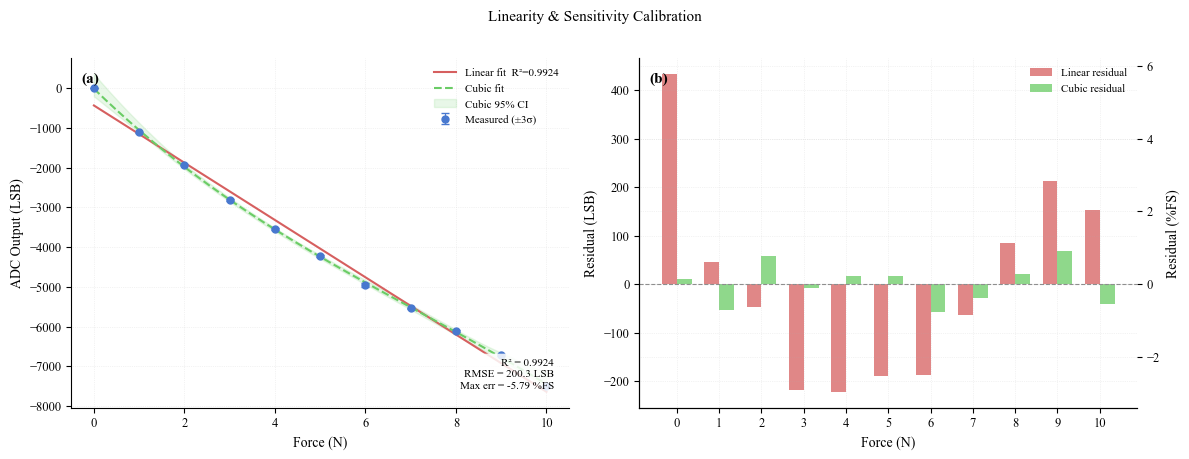

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test3\png\03a_calibration.png
Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test3\png\03b_residuals.png


In [8]:
# ── Fig 1: 2-panel linearity ──────────────────────────────────────────────────
# (a) scatter + linear fit + cubic fit with 95% CI
# (b) residuals of both fits

# Cubic polynomial fit
poly3_coeffs = np.polyfit(forces, outputs, 3)
poly3 = np.poly1d(poly3_coeffs)
y_pred_poly3 = poly3(forces)
residuals_poly3 = outputs - y_pred_poly3

# 95% CI for cubic fit via bootstrap
n_boot = 500
force_fine = np.linspace(forces.min(), forces.max(), 200)
boot_preds = np.zeros((n_boot, len(force_fine)))
rng = np.random.default_rng(42)
for b in range(n_boot):
    idx = rng.integers(0, len(forces), len(forces))
    c = np.polyfit(forces[idx], outputs[idx], 3)
    boot_preds[b] = np.poly1d(c)(force_fine)
ci_lo = np.percentile(boot_preds, 2.5, axis=0)
ci_hi = np.percentile(boot_preds, 97.5, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) calibration curve
ax = axes[0]
ax.errorbar(forces, outputs, yerr=3*stds, fmt="o",
            color=COLORS["data"], capsize=3, elinewidth=0.8,
            markersize=5, label="Measured (±3σ)")
force_fit = np.linspace(forces.min(), forces.max(), 200)
ax.plot(force_fit, slope * force_fit + intercept,
        color=COLORS["fit"], linewidth=1.5, label=f"Linear fit  R²={R2:.4f}")
ax.plot(force_fit, poly3(force_fit),
        color=COLORS["green"], linewidth=1.5, linestyle="--", label="Cubic fit")
ax.fill_between(force_fine, ci_lo, ci_hi,
                color=COLORS["green"], alpha=0.15, label="Cubic 95% CI")
ax.set_xlabel("Force (N)"); ax.set_ylabel("ADC Output (LSB)")
ax.text(0.97, 0.05,
        f"R² = {R2:.4f}\nRMSE = {RMSE:.1f} LSB\nMax err = {nonlinearity_FS:.2f} %FS",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
ax.legend(frameon=False, fontsize=8)
add_subplot_label(ax, "(a)")

# (b) residuals comparison
ax = axes[1]
w = 0.35
x_pos = np.arange(len(forces))
ax.bar(x_pos - w/2, residuals,       width=w, color=COLORS["fit"],   alpha=0.75,
       edgecolor="none", label="Linear residual")
ax.bar(x_pos + w/2, residuals_poly3, width=w, color=COLORS["green"], alpha=0.75,
       edgecolor="none", label="Cubic residual")
ax.axhline(0, color=COLORS["gray"], linewidth=0.8, linestyle="--")
ax.set_xticks(x_pos); ax.set_xticklabels([f"{f:.0f}" for f in forces])
ax.set_xlabel("Force (N)"); ax.set_ylabel("Residual (LSB)")
ax2b = ax.twinx()
ax2b.set_ylabel("Residual (%FS)")
ax2b.set_ylim(ax.get_ylim()[0] / abs(full_scale) * 100,
              ax.get_ylim()[1] / abs(full_scale) * 100)
ax2b.spines["top"].set_visible(False)
ax.legend(frameon=False, fontsize=8)
add_subplot_label(ax, "(b)")

fig.suptitle("Linearity & Sensitivity Calibration", fontsize=11, y=1.01)
plt.tight_layout()
p = save_figure(fig, SAVE_DIR, "03_linearity_overview")
print(f"Saved: {p}")
plt.show()

# ── Individual sub-figures ────────────────────────────────────────────────────
for i, stem in enumerate(["03a_calibration", "03b_residuals"]):
    fig_s, ax_s = plt.subplots(figsize=(6, 4.5))
    if i == 0:
        ax_s.errorbar(forces, outputs, yerr=3*stds, fmt="o",
                      color=COLORS["data"], capsize=3, elinewidth=0.8, markersize=5)
        ax_s.plot(force_fit, slope * force_fit + intercept,
                  color=COLORS["fit"], linewidth=1.5)
        ax_s.plot(force_fit, poly3(force_fit),
                  color=COLORS["green"], linewidth=1.5, linestyle="--")
        ax_s.fill_between(force_fine, ci_lo, ci_hi, color=COLORS["green"], alpha=0.15)
        ax_s.set_xlabel("Force (N)"); ax_s.set_ylabel("ADC Output (LSB)")
        ax_s.text(0.97, 0.05,
                  f"R² = {R2:.4f}\nRMSE = {RMSE:.1f} LSB\nMax err = {nonlinearity_FS:.2f} %FS",
                  transform=ax_s.transAxes, ha="right", va="bottom", fontsize=8,
                  bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
    else:
        ax_s.bar(x_pos - w/2, residuals,       width=w, color=COLORS["fit"],   alpha=0.75, edgecolor="none")
        ax_s.bar(x_pos + w/2, residuals_poly3, width=w, color=COLORS["green"], alpha=0.75, edgecolor="none")
        ax_s.axhline(0, color=COLORS["gray"], linewidth=0.8, linestyle="--")
        ax_s.set_xticks(x_pos); ax_s.set_xticklabels([f"{f:.0f}" for f in forces])
        ax_s.set_xlabel("Force (N)"); ax_s.set_ylabel("Residual (LSB)")
        ax2s = ax_s.twinx()
        ax2s.set_ylabel("Residual (%FS)")
        ax2s.set_ylim(ax_s.get_ylim()[0] / abs(full_scale) * 100,
                      ax_s.get_ylim()[1] / abs(full_scale) * 100)
        ax2s.spines["top"].set_visible(False)
    plt.tight_layout()
    p = save_figure(fig_s, SAVE_DIR, stem)
    print(f"Saved: {p}")
    plt.close(fig_s)

#### 9. 各测试点误差分析

In [9]:
print("各测试点线性度误差:")
print("-"*70)
print(f"{'Force (N)':<12} {'Measured':<12} {'Predicted':<12} {'Error (LSB)':<12} {'Error (%FS)':<12}")
print("-"*70)

for i in range(len(forces)):
    error_FS = residuals[i] / full_scale * 100
    print(f"{forces[i]:<12.1f} {outputs[i]:<12.2f} {y_pred[i]:<12.2f} "
          f"{residuals[i]:<12.3f} {error_FS:<12.4f}")

各测试点线性度误差:
----------------------------------------------------------------------
Force (N)    Measured     Predicted    Error (LSB)  Error (%FS) 
----------------------------------------------------------------------
0.0          4.06         -429.73      433.790      -5.7865     
1.0          -1104.72     -1151.24     46.527       -0.6206     
2.0          -1920.22     -1872.76     -47.466      0.6332      
3.0          -2813.58     -2594.27     -219.310     2.9255      
4.0          -3538.07     -3315.79     -222.281     2.9651      
5.0          -4226.21     -4037.30     -188.910     2.5199      
6.0          -4947.05     -4758.81     -188.231     2.5109      
7.0          -5544.41     -5480.33     -64.083      0.8548      
8.0          -6117.80     -6201.84     84.039       -1.1210     
9.0          -6709.77     -6923.36     213.584      -2.8491     
10.0         -7492.53     -7644.87     152.340      -2.0321     


#### 10. 结果汇总与保存

In [10]:
# 保存标定参数
calibration_params = {
    'Sensitivity_LSB_per_N': slope,
    'Sensitivity_mV_per_N': slope * LSB * 1000,
    'Zero_Offset_LSB': intercept,
    'Full_Scale_LSB': full_scale,
    'R2': R2,
    'RMSE_LSB': RMSE,
    'Nonlinearity_LS_percentFS': nonlinearity_FS,
    'Nonlinearity_EP_percentFS': endpoint_nonlinearity
}
pd.DataFrame([calibration_params]).to_csv('03_calibration_params.csv', index=False)

# 保存标定数据
df_cal = pd.DataFrame({
    'Folder': loaded_folders,
    'Force_N': forces,
    'Output_LSB': outputs,
    'Std_LSB': stds,
    'Predicted_LSB': y_pred,
    'Residual_LSB': residuals
})
df_cal.to_csv('03_calibration_data.csv', index=False)

print("="*60)
print("【实验03 结果汇总】")
print("="*60)
print(f"""
┌─────────────────────────────────────────────────────────┐
│  线性度与灵敏度测试结果                                  │
├─────────────────────────────────────────────────────────┤
│  标定方程:                                              │
│    Output = {slope:.4f} × Force + {intercept:.4f}             │
├─────────────────────────────────────────────────────────┤
│  灵敏度:         {slope:>10.4f} LSB/N                   │
│  灵敏度:         {slope * LSB * 1000:>10.4f} mV/N                    │
│  满量程跨度:     {full_scale:>10.2f} LSB                    │
├─────────────────────────────────────────────────────────┤
│  R² 决定系数:    {R2:>10.6f}                        │
│  RMSE:           {RMSE:>10.4f} LSB                    │
│  最小二乘线性度: {nonlinearity_FS:>10.4f} %FS                  │
│  端基线性度:     {endpoint_nonlinearity:>10.4f} %FS                  │
└─────────────────────────────────────────────────────────┘
""")

print("标定参数已保存至: 03_calibration_params.csv")
print("标定数据已保存至: 03_calibration_data.csv")

【实验03 结果汇总】

┌─────────────────────────────────────────────────────────┐
│  线性度与灵敏度测试结果                                  │
├─────────────────────────────────────────────────────────┤
│  标定方程:                                              │
│    Output = -721.5141 × Force + -429.7295             │
├─────────────────────────────────────────────────────────┤
│  灵敏度:          -721.5141 LSB/N                   │
│  灵敏度:          -110.0943 mV/N                    │
│  满量程跨度:       -7496.59 LSB                    │
├─────────────────────────────────────────────────────────┤
│  R² 决定系数:      0.992354                        │
│  RMSE:             200.2748 LSB                    │
│  最小二乘线性度:    -5.7865 %FS                  │
│  端基线性度:        -7.5857 %FS                  │
└─────────────────────────────────────────────────────────┘

标定参数已保存至: 03_calibration_params.csv
标定数据已保存至: 03_calibration_data.csv
